# ML Rydberg Workflow

In [19]:
import qkernel
import numpy as np
import matplotlib.pyplot as plt
import snag
from sklearn.metrics import r2_score

## Generate Data

In [2]:
spacing = 1.5
p_ref = np.arange(2)*spacing
r_size = 0.2

def create_distortions(n):
    return p_ref + np.random.uniform(-r_size, r_size, (n, 2))

In [3]:
q_train = create_distortions(200)
d_train = np.abs(q_train[:, 0] - q_train[:, 1]).flatten()

q_test = create_distortions(100)
d_test = np.abs(q_test[:, 0] - q_test[:, 1]).flatten()

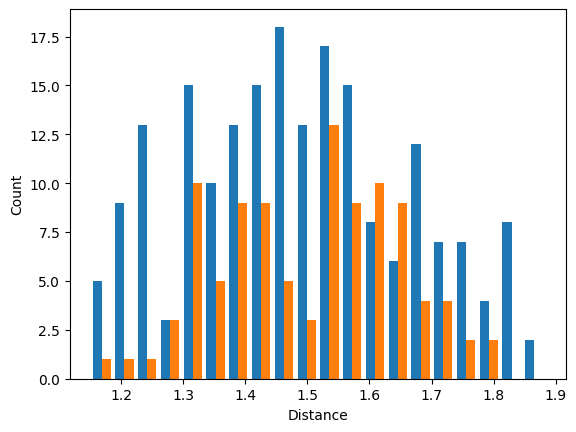

In [4]:
plt.hist([d_train, d_test], bins=20)
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

## Run Neutral Atom sims

In [5]:
def compute_probs(qs, scaling_fac=7):
    ham = qkernel.hamiltonian.QuTiPHamiltonian(qs * scaling_fac)
    sim = qkernel.simulator.QuTiPSimulator(ham.generate_hamiltonians_list())
    return np.array(sim.get_probabilities_list())[:, :, 0]

In [6]:
p_train = compute_probs(q_train[:, :, None])
p_test = compute_probs(q_test[:, :, None])

kernel = qkernel.kernel.Kernel(p_train=p_train, p_test=p_test, distance_fn="exp_js")
g_train = kernel.compute_gram_train()
g_test = kernel.compute_gram_test()

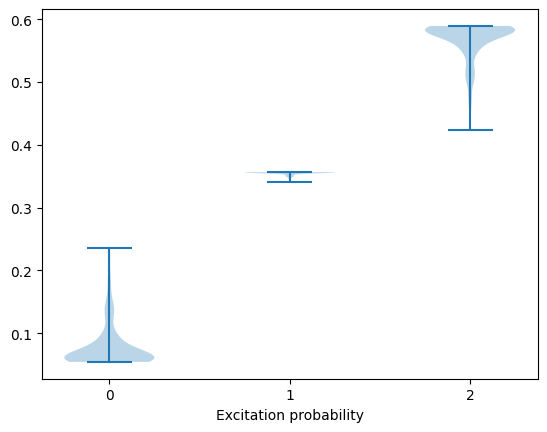

In [7]:
#plt.hist(kernel.p_train[:, 0])
plt.violinplot(kernel.p_train)
plt.xticks(range(1, 4), range(3))
plt.xlabel("Excitation probability")
plt.show()

## Solve Hubbard

In [8]:
def radial_hopping(r):
    return 1.0 / r**3

u = 3.

def solve_hubbard(d):
    hopping = radial_hopping(d)
    t_mat = np.array([[0.0, hopping], [hopping, 0.0]])
    calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=2)
    ham = calc.hopping(t_mat) + u * np.diag(calc.doubles())
    return np.linalg.eigvalsh(ham)[0]

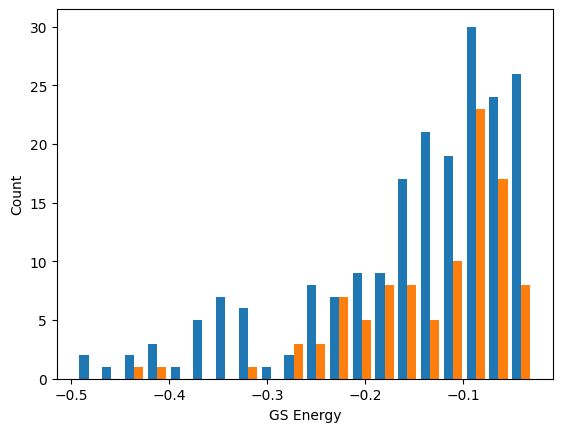

In [9]:
e_train = np.array([solve_hubbard(t) for t in d_train])
e_test = np.array([solve_hubbard(t) for t in d_test])

plt.hist([e_train, e_test], bins=20)
plt.xlabel("GS Energy")
plt.ylabel("Count")
plt.show()

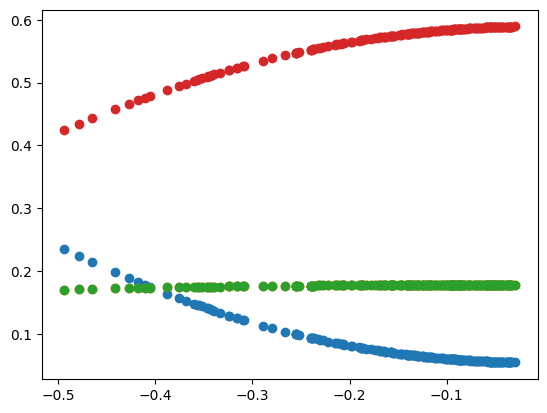

In [10]:
plt.scatter(e_train, p_train[:, 0])
plt.scatter(e_train, p_train[:, 1])
plt.scatter(e_train, p_train[:, 2])
plt.scatter(e_train, p_train[:, 3])

## Fit Model

In [11]:
model = qkernel.model.KRR(alpha=1e-8)
model.train(g_train, e_train)
pred_train = model.predict(g_train)
pred_test = model.predict(g_test)

In [22]:
print("r2 train:", r2_score(e_train, pred_train))
print("r2 test:", r2_score(e_test, pred_test))

r2 train: 0.9994852497274812
r2 test: 0.9991365636266618


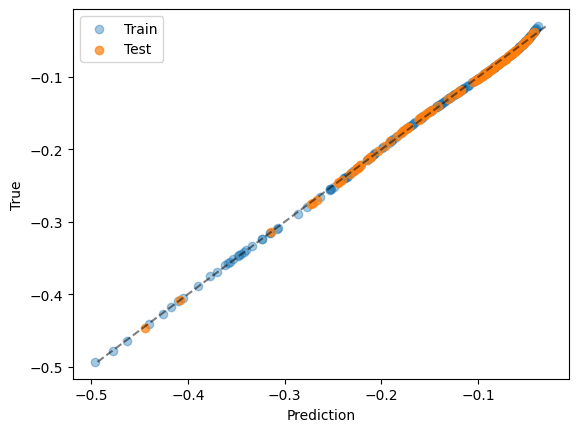

In [18]:
plt.scatter(pred_train, e_train, alpha=0.4, label="Train")
plt.scatter(pred_test, e_test, alpha=0.7, label="Test")
plt.xlabel("Prediction")
plt.ylabel("True")

bounds = [min(e_train), max(e_train)]
plt.legend()
plt.plot(bounds, bounds, ls="--", c="k", alpha=0.5)
plt.show()